<a href="https://colab.research.google.com/github/ldaniel-hm/eml_tabular/blob/main/MonteCarloTodasLasVisitas.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Grupo 2: Taxi para comparativa de modelos tabulares**

Autor:

- Miguel Ángel Ortiz Peñaranda


## Introducción

El objetivo de este notebook es establecer una comparativa en cuanto a desempeño para distintos agentes de aprendizaje por refuerzo que siguen el modelo **tabular**. El modelo tabular almacena una tabla Q(s, a), donde se indica, para cada posible estado de un problema y cada posible acción a realizar, el valor esperado del retorno de la misma. De esta forma, durante la interacción con el entorno como los que nos encontramos en _gymnasium_, el agente es entrenado para elegir la acción más ventajosa dependiendo del estado en el que se encuentre, siguiendo una política determinada.

Los modelos tabulares presentan una serie de ventajas claras:

- Son sencillos de implementar y de comprender, tanto a nivel de funcionamiento como a nivel de resultados.
- Existen garantías de que los modelos acaben convergiendo hacia una política óptima.
- Para entornos discretos presentan un buen desempeño si son configurados correctamente. Su entrenamiento es también por lo general bastante rápido, pues acceder a cada celda es inmediato.

Sin embargo, traen consigo también una serie de desventajas inherentes a su funcionamiento:
- Al almacenar una matriz bidimensional por cada par estado-acción, tenemos que esta tabla crece desproporcionadamente cuando el número de estados o acciones posibles es grande. Esto puede acabar suponiendo un problema de memoria cuando la tabla es significativa.
- Estos agentes funcionan bien para conjuntos de estados y acciones discretos, pero son incapaces de resolver problemas cuyos conjuntos sean continuos, pues son valores para los que no es posible confeccionar una tabla.
- No son capaces de generalizar. Aprenden el valor para un estado concreto, pero no tienen la capacidad de extrapolar ese aprendizaje a estados que sean similares.

## Descripción del entorno

En este notebook en particular, nos centraremos en el problema de _gymnasium_ **Taxi**, que trata de guiar un agente a lo largo y ancho de un mapa de celdas, de forma que recoja a un pasajero en una de las cuatro celdas previamente designadas (es aleatorio), identificadas con los colores rojo, verde, amarillo y azul, y lo deposite en otra de las cuatro celdas.

El mapa por defecto tiene la siguiente estructura:

```
+---------+
|R: | : :G|
| : | : : |
| : : : : |
| | : | : |
|Y| : |B: |
+---------+
```

El conjunto de posibles acciones contempladas en este entorno es el siguiente:

- 0: Moverse abajo
- 1: Moverse arriba
- 2: Moverse a la derecha
- 3: Moverse a la izquierda
- 4: Recoger a un pasajero
- 5: Dejar a un pasajero

El conjunto de estados es de 500 en total, incluyendo 25 posibles posiciones para el taxi, 5 posibles posiciones para el pasajero, incluyendo la casuística de que el pasajero está en el taxi, y 4 casillas de destino.

En cuanto a las recompensas, tenemos:

- -1 por paso a no ser que se active otra recompensa
- +20 por dejar a un pasajero
- -10 por realizar acciones de recoger a un pasajero o dejarlo de forma que no estén permitidas (como intentar depositar a alguien sin llevar un pasajero en el taxi).

El episodio termina cuando se deja a un pasajero, o se alcanza el límite de 200 pasos.

Existe otra casuística en el entorno como configurar que llueva, `is_rainy`, o que el pasajero pueda cambiar de ubicación a otra aleatoria cuando estamos cerca `fickle_passenger`, que introducen un comportamiento estocástico en este entorno, aumentando su dificultad, y que nosotros vamos a evitar en aras de la sencillez.

## Metodología de trabajo

Se propone una metodología de trabajo en la que se va a probar, tanto con distintas variantes del entorno, como con distintas variantes de los agentes tabulares, el desempeño para cada agente. Siendo así, seguiremos los siguientes pasos:

1. Para cada entorno, entrenaremos todos los tipos de agentes tabulares comprendidos.
2. Se obtendrán una serie de estadísticas que nos permitan graficar la recompensa obtenida por cada agente a lo largo del tiempo, y la evolución de la longitud de cada episodio, en _steps_.
3. Se comparará la mejor recompensa obtenida por el agente con el resto de agentes, y la mejor longitud de episodio que es capaz de conseguir con la del resto de agentes y con la óptima.
4. Se pomediarán los resultados obtenidos para cada entorno, para cada agente.
5. Se darán unas conclusiones finales que indiquen qué algoritmo o algoritmos se considera que presentan un mejor comportamiento.

## 1. Preparación del Entorno

La preparación consta de las siguientes partes:
- **Instalación de Dependencias**: Se instalan las librerías necesarias para utilizar el entorno `gymnasium` para la simulación, con el objetivo de crear un ambiente controlado para que el agente pueda interactuar.
- **Importación de Librerías**: Se importan las bibliotecas necesarias como `numpy` para el manejo de matrices y `matplotlib` para la visualización de los resultados.

- **Importación del Entorno "Taxi"**:
Se carga el entorno de Taxi que hemos comentado anteriormente.

- **Importación de las implementaciones de los agentes**:
Se importarán las implementaciones existentes bajo src/ de los agentes tabulares que deseamos comparar
  - Monte Carlo On Policy
  - Monte Carlo Off Policy
  - SARSA
  - QLearning


In [3]:
!pip install 'gym[box2d]==0.20.0'

## Instalación de paquetes adicionales para uso en colab
!apt-get update
!apt install swig
!pip install gymnasium[box2d]

In [ ]:
!rm -r exml-ortizpenaranda/
!git clone https://github.com/miguelangelortizpenaranda/exml-ortizpenaranda.git
!cd exml-ortizpenaranda/

In [ ]:
#@title Importamos todas las clases y funciones
import sys


# Añadir los directorios fuentes al path de Python
sys.path.append('/content/exml-ortizpenaranda/entornos_complejos/src/eml_complex_environments')
sys.path.append('src/eml_complex_environments')

# Verificar que se han añadido correctamente
print(sys.path)


In [4]:
from tqdm import tqdm
import gymnasium as gym

from src.eml_complex_environments.agents import *
from src.eml_complex_environments.util import *

A continuación vamos a crear la instancia del entorno Taxi.

Como hemos comentado, fijamos el parámetro `is_rainy=False` para asegurarnos que los movimientos son deterministas, y el parámetro de `fickle_passeenger=False` para asegurarnos que el pasajero no cambia de posición.

In [5]:
name = 'Taxi-v4'
env = gym.make(name, is_rainy=False, fickle_passenger=False, render_mode="ansi")

Establecemos también una semilla aleatoria y se la fijamos a _numpy_, de forma que, cuando intentemos obtener algún número aleatorio, obtengamos los mismos de forma consistente
entre distintas ejecuciones del programa, en distintos equipos.

In [6]:
random_seed = 123
np.random.seed(random_seed)

## 2. Diseño de los agentes y algoritmo de entrenamiento

Cada agente queda representado por una clase distinta, que implementa el algoritmo que sigue para realizar el proceso de aprendizaje y la toma de decisiones. Todos los agentes
heredan de la clase abstracta **TabularAgent**, que presenta los siguientes métodos:

- `get_action`: En base al estado actual en el que se encuentre el agente, toma una acción usando una política. La política que vamos a utilizar cuando el agente está aprendiendo es una política epsilon-greedy, que permite que se "explote" la mejor acción conocida la mayoría del tiempo, pero permite "explorar" nuevas acciones con una probabilidad determinada. Esta política se deriva de una epsilon-soft, donde varias acciones pueden tener una probabilidad determinada de ser elegidas. Si establecemos que se utilice epsilon-decay, esta probabilidad de explorar irá decreciendo conforme nos acerquemos al final del entrenamiento del agente. Cuando el agente haya sido entrenado, utilizaremos una política puramente greedy, que elegirá siempre la mejor acción conocida para cada estado.
- `on_episode_step`: Este método será llamado para cada agente cuando se realice un cambio de estado en un episodio (el agente realice una acción). Como, en base a esa acción, obtenemos una recompensa y un nuevo estado, podemos usar esos valores para que cada agente actualice su estado interno. Los agentes como los que usan diferencias temporales actualizarán su tabla interna en este método, mientras que las variantes de Monte Carlo lo harán al terminar el episodio.
- `on_episode_finished`: Se llamará a este método cuando el agente haya finalizado un episodio, ya sea porque ha llegado al objetivo o porque ha terminado abruptamente. Cada agente realizará las acciones pertinentes en este caso. Por ejemplo, Monte Carlo iterará por todos los pasos dados para actualizar su tabla.


El siguiente método `run_agent` recibe como parámetro la clase genérica de tipo `Agent`, de forma que sea agnóstico a la implementación del agente que se va a entrenar. Realizará las siguientes acciones:

- Iterará por un número especificado de episodios en el entorno especificado, en cada cual el agente intentará resolver el problema y llegar al objetivo.
- Para cada episodio puede darse el caso de que se termine de forma natural (el taxi deje al pasajero), o que haya sido truncado, porque exista un número máximo de pasos, o _steps_, configurados para ese episodio, de forma que el agente no pueda quedarse de forma infinita estancado en el mismo.
- Se calcularán durante el transcurso del entrenamiento las estadísticas de promedio de recompensas acumuladas por episodio, y longitud de cada episodio, de cara a graficar el comportamiento de cada agente

In [7]:

def run_agent(agent, env, num_episodes=5000):
  """
  Entrena al agente especificado, en un entorno concreto, a lo largo de un número de episodios. Obtiene algunas métricas
  que se utilizarán posteriormente para graficar el comportamiento del agente.
  :param agent: Agente que se va a entrenar
  :param env: Entorno de gymnasium en el que se va a entrenar el agente
  :param num_episodes: Número de episodios en los que se va a comprender el entrenamiento
  :return: tabla Q del agente, lista de recompensas acumuladas, lista de longitud de cada episodio, número de episodios completados correctamente, y promedio de longitud de episodio correcto
  """
  # Para mostrar la evolución en el terminal y algún dato que mostrar
  stats = 0.0
  list_stats = [stats]
  step_display = num_episodes / 10
  lengths = 0.0
  episode_lengths = [lengths]
  n_correct_finished_episodes = 0
  sum_correct_episode_lengths = 0
  avg_correct_episode_length = 0.0

  for t in tqdm(range(num_episodes)):
      current_state, info = env.reset(seed=random_seed+t) # Esto hace que los episodios empiecen distinto, cambiando la semilla
      agent.set_initial_state(current_state)
      done = False
      while not done:
          action = agent.get_action(current_state)
          new_state, reward, episode_finished, truncated, info = env.step(action)
          done = episode_finished or truncated
          agent.on_episode_step(new_state, action, reward, t, episode_finished)
          current_state = new_state
          if episode_finished and reward == 20:
            n_correct_finished_episodes += 1
            sum_correct_episode_lengths += agent.get_episode_len()

      episode_lengths.append(agent.get_episode_len())
      result_sum = agent.on_episode_finished()

      # Guardamos datos sobre la evolución. Promedio de recompensas
      stats += result_sum
      avg_stat = stats/(t+1)
      list_stats.append(avg_stat)

      current_epsilon = agent.get_current_epsilon()
      # Para mostrar la evolución.  Comentar si no se quiere mostrar
      if t % step_display == 0 and t != 0:
          print(f"success: {stats/t}, epsilon: {current_epsilon}")

  if n_correct_finished_episodes > 0:
    avg_correct_episode_length = sum_correct_episode_lengths / n_correct_finished_episodes

  return agent.get_q_table(), list_stats, episode_lengths, n_correct_finished_episodes, avg_correct_episode_length


Definimos también el método `run_agents` que nos permite hacer lo propio pero para un conjunto de agentes. En un diccionario se almacenará, usando como clave el nombre de cada agente:
- La Q table de ese agente tras su entrenamiento
- La proporción de recompensas para ese agente
- La longitud de cada episodio para ese agente
- El número total de episodios completados correctamente (llegando a la casilla objetivo) por ese agente
- El promedio de la longitud de los episodios terminados correctamente, en _steps_

In [8]:
def run_agents(agents, env, num_episodes):
    """
    Entrena un conjunto de agentes en un entorno determinado, obteniendo métricas de su desempeño para almacenarlas y más tarde
    devolverlas cuando termine el entrenamiento del conjunto
    :param agents: Conjunto de agentes a entrenar
    :param env: entorno en el que se entrenarán los agentes
    :param num_episodes: número de episodios para los cuales se realizará el entrenamiento
    :return: tabla Q de los agentes, listas de recompensas acumuladas, listas de longitudes de cada episodio, número de episodios completados correctamente, y promedio de longitud de episodio correcto
    """
    agent_q_tables = {}
    agent_stats = {}
    agent_episode_lengths = {}
    agent_correct_finished_episodes = {}
    agent_avg_correct_episode_lengths = {}

    for agent in agents:
        agent_name = agent.get_name()
        print(f'\nRunning agent {agent_name}')
        q_table, list_stats, episode_lengths, n_correct_finished_episodes, avg_correct_episode_length = run_agent(agent, env, num_episodes)
        agent_q_tables[agent_name] = q_table
        agent_stats[agent_name] = list_stats
        agent_episode_lengths[agent_name] = episode_lengths
        agent_correct_finished_episodes[agent_name] = n_correct_finished_episodes
        agent_avg_correct_episode_lengths[agent_name] = avg_correct_episode_length

    return agent_q_tables, agent_stats, agent_episode_lengths, agent_correct_finished_episodes, agent_avg_correct_episode_lengths

Se define asimismo un método de apoyo, `create_agents`, que nos permita crear todos los agentes que se van a evaluar parametrizados

In [9]:
def create_agents(env, epsilon, discount_factor, epsilon_decay):
    """
    Crea todos los agentes tabulares para los que se va a realizar el entrenamiento y comparativa. Admite los parámetros con los que se va a probar
    en la experimentación.
    :param env: Entorno sobre el que se va a entrenar a los agentes
    :param epsilon: Factor que determina cómo de exploratorio es el agente
    :param discount_factor: Factor de descuento para el retorno futuro (1.0 = no se realiza descuento sobre valor futuro)
    :param epsilon_decay: Indica si el factor epsilon va decreciendo
    :return: array con todos los agentes parametrizados
    """
    monte_carlo_on_policy = MonteCarloOnPolicy(environment=env, epsilon=epsilon, discount_factor=discount_factor, random_seed=random_seed, epsilon_decay=epsilon_decay)
    monte_carlo_off_policy = MonteCarloOffPolicy(environment=env, epsilon=epsilon, discount_factor=discount_factor, random_seed=random_seed, epsilon_decay=epsilon_decay)
    sarsa = SARSA(environment=env, epsilon=epsilon, discount_factor=discount_factor, learning_rate=0.1, random_seed=random_seed, epsilon_decay=epsilon_decay)
    qlearning = QLearning(environment=env, epsilon=epsilon, discount_factor=discount_factor, learning_rate=0.1, random_seed=random_seed, epsilon_decay=epsilon_decay)
    return [monte_carlo_on_policy, monte_carlo_off_policy, sarsa, qlearning]

## 3. Ejecución del experimento

En esta sección se va a proceder, dado el algoritmo y los agentes implementados previamente, a evaluar su desempeño en el entorno de Taxi.

Vamos a probar todos los agentes con las siguientes variaciones en sus parámetros:

- **epsilon** = [0.4, 0.5, 0.6]
- **discount_factor** = [1, 0.9]
- **epsilon_decay** = [True, False]

De esta forma podemos observar cómo se comportan los agentes con distintas componentes exploratorias, así como para distintos factores de descuento para el retorno
futuro que se obtiene de la tabla Q(s, a). El uso de epsilon decaimiento supondrá que el algoritmo se volverá más greedy y menos exploratorio por cierto conforme
el agente va llegando a los últimos episodios, es decir, explotará únicamente la política aprendida y apenas no explorará, en contraste con al principio del algoritmo,
que actuará de forma prácticamente aleatoria.

Se visualizará para la comparativa:
- Proporción máxima de recompensas que ha obtenido el agente
- Número total de episodios que han terminado correctamente
- Promedio de longitud de los episodios que han terminado correctamente

Al final de la experimentación promediaremos estos valores para ver que agente ha conseguido, de forma general, obtener mejores resultados.

Graficaremos también:

- La evolución de la proporción de recompensas (nos dirá el porcentaje de veces que el agente ha llegado al estado terminal)
- La longitud de los episodios para poder visualizar de qué forma y a qué ritmo aprenden los agentes a desenvolverse por el entorno.

Para apoyar a la visualización de los resultados, es posible que se muestre los valores de Q para cada par estado-acción, de forma que se vea, para cada estado, como valora el agente cada acción. Mostraremos también la política óptima del mismo.


Todos los métodos usados para esta impresión y visualización se pueden localizar en el paquete `src/util` de la práctica.

### Experimentación

Procedemos a la experimentación para este entorno. Dado que cada nuevo episodio supone un punto de inicio aleatorio para el taxi, y para el usuario a recoger (A diferencia de en Frozen Lake, que eran fijos), no tenemos forma de saber, a priori, el número mínimo de pasos, puesto que depende de como se haya dispuesto el entorno en cada caso.

Se entrenará a los agentes, al igual que con el entorno de Frozen Lake, a lo largo de **50000 episodios**, y veremos las métricas que obtiene cada uno para realizar una comparativa entre los mismos. Vamos a realizar una búsqueda de hiperparámetros para intentar determinar, no solo qué agentes se comportan mejor, sino qué parámetros son los más deseables de entre los contemplados para dirigir su entrenamiento.



In [10]:
num_episodes = 50000

En primer lugar, vamos a utilizar un grid search entre valores para epsilon fijos y valores para el factor de descuento para ver qué algoritmo se comporta mejor. Definimos la función `run_experiment_using_grid_search` de forma a aportar algo de genericidad a la experimentación. Solo hemos de pasar el entorno y el grid de parámetros deseado y la propia función ya obtiene todas las estadísticas, para todos los agentes, para todas las combinaciones de parámetros que se le den.


In [11]:
import itertools

def run_experiment_using_grid_search(env, param_grid):
    """
    Entrena una serie de agentes y obtiene distintas métricas utilizando un grid de parámetros
    Se realizarán tantos entrenamientos como posibles combinaciones de parámetros existan en el grid
    :param env: entorno sobre el que se realizará el entrenamiento
    :param param_grid: grid de parámetros con los que se realizarán los entrenamientos
    :return: tabla Q de los agentes, listas de recompensas acumuladas, listas de longitudes de cada episodio, número de episodios completados correctamente, y promedio de longitud de episodio correcto,
    para cada una de las combinaciones de parámetros
    """
    results_q_tables = {}
    results_stats = {}
    results_episode_lengths = {}
    results_correct_finished_episodes = {}
    results_avg_correct_episode_lengths = {}

    # Itera por el grid de parámetros, realizando todas las combinatorias
    for epsilon, discount_factor, epsilon_decay in itertools.product(param_grid["epsilon"], parameters["discount_factor"], parameters["epsilon_decay"]):
        print(f'\nParameter values: epsilon: {epsilon}, discount_factor: {discount_factor}\n')

        agents = create_agents(env, epsilon, discount_factor, epsilon_decay) # Crea los distintos agentes

        # Ejecuta el experimento para todos los agentes, con estos parámetros en particular
        agent_q_tables, agent_stats, agent_episode_lengths, agent_correct_finished_episodes, agent_avg_correct_episode_lengths = run_agents(agents, env, num_episodes=num_episodes)

        key = (epsilon, discount_factor)
        results_q_tables[key] = agent_q_tables
        results_stats[key] = agent_stats
        results_episode_lengths[key] = agent_episode_lengths
        results_correct_finished_episodes[key] = agent_correct_finished_episodes
        results_avg_correct_episode_lengths[key] = agent_avg_correct_episode_lengths

    return results_q_tables, results_stats, results_episode_lengths, results_correct_finished_episodes, results_avg_correct_episode_lengths

Definimos el grid de parámetros y ejecutamos el experimento con los agentes definidos previamente. El grid de parámetros va a ser el mismo que el que hemos usado en el otro Notebook. Se muestra información durante el entrenamiento de los agentes, como la proporción de recompensas y epsilon, que recordemos en estos casos se mantendrá fijo puesto que no utilizamos epsilon decay.

In [12]:

parameters = {
    'epsilon': [0.3, 0.4, 0.5],
    'discount_factor': [1.0, 0.9],
    'epsilon_decay': [False]
}

results_q_tables, results_stats, results_episode_lengths, results_correct_finished_episodes, results_avg_correct_episode_lengths = run_experiment_using_grid_search(env, parameters)



Parameter values: epsilon: 0.3, discount_factor: 1.0


Running agent MonteCarloOnPolicy


 10%|█         | 5108/50000 [00:15<02:01, 368.06it/s]

success: -308.3268, epsilon: 0.3


 20%|██        | 10080/50000 [00:26<01:27, 454.59it/s]

success: -246.5126, epsilon: 0.3


...

 80%|████████  | 40138/50000 [00:36<00:08, 1173.85it/s]

success: -53.194175, epsilon: 0.5


 91%|█████████ | 45445/50000 [00:40<00:02, 1524.42it/s]

success: -52.59217777777778, epsilon: 0.5


100%|██████████| 50000/50000 [00:43<00:00, 1141.24it/s]


Tras la ejecución para este entorno, podemos ver como todos los métodos consiguen aprender una política óptima para resolver el problema. En general, es Monte Carlo On-Policy el que peores resultados ha ofrecido, si bien consigue terminar una cantidad significativa de episodios correctamente. Sin embargo, el resto de métodos, no solo consiguen terminar un número mayor de episodios que Monte Carlo On-Policy, sino que, una vez aprenden la política, que es realmente rápido, terminan con éxito casi la totalidad de los restantes.

Vemos de esta forma como SARSA o Q-Learning llegan casi a la totalidad de los episodios completados correctamente. Monte-Carlo Off-Policy también logra un número significativo aunque con peores resultados que los que utilizan diferencias temporales, probablemente porque, al evaluarse y modificarse la política solo al final de cada episodio, tarda más en converger (algo parecido sucede con Monte Carlo On-Policy). Un número de episodios más elevado para el entrenamiento probablemente hiciera que dieran mejor resultado estos métodos.

In [13]:
for epsilon, discount_factor in itertools.product(parameters["epsilon"], parameters["discount_factor"]):
    print(f'\nParameter values: epsilon: {epsilon}, discount_factor: {discount_factor}\n')
    key = (epsilon, discount_factor)
    print_max_reward_proportion_for_agents(results_stats[key])
    print('\n')
    print_max_correctly_finished_episodes_for_agents(results_correct_finished_episodes[key])
    print('\n')
    print_correct_finished_episodes_length_avg_for_agents(results_avg_correct_episode_lengths[key])



Parameter values: epsilon: 0.3, discount_factor: 1.0

[MonteCarloOnPolicy] Máxima proporcion recompensa: -127.15004
[MonteCarloOffPolicy] Máxima proporcion recompensa: -56.28486
[SARSA] Máxima proporcion recompensa: -19.75948
[QLearning] Máxima proporcion recompensa: -17.23504


[MonteCarloOnPolicy] Episodios terminados correctamente: 36961
[MonteCarloOffPolicy] Episodios terminados correctamente: 47707
[SARSA] Episodios terminados correctamente: 49740
[QLearning] Episodios terminados correctamente: 49809


[MonteCarloOnPolicy] Promedio de longitud por episodio completado correctamente: 31.3162522659019
[MonteCarloOffPolicy] Promedio de longitud por episodio completado correctamente: 25.356551449472825
[SARSA] Promedio de longitud por episodio completado correctamente: 21.41166063530358
[QLearning] Promedio de longitud por episodio completado correctamente: 20.376759220221246

Parameter values: epsilon: 0.3, discount_factor: 0.9

[MonteCarloOnPolicy] Máxima proporcion recompensa: -196

Mostramos también, para todos los resultados obtenidos anteriormente, cuáles son los mejores en términos absolutos, en cuanto a mayor número de episodios completados y longitud promedio de los episodios.

Q-Learning ha mostrado ser, en ambos casos, el mejor. Con 49809 episodios completados correctamente, y una longitud promedio de 20.38 pasos para los episodios completados, obtiene sus mejores resultados para un epsilon de 0.3 y un factor de descuento del retorno futuro de 1.0.

In [14]:
print_global_best_for_finished_episodes(results_correct_finished_episodes)
print_global_best_for_episodes_length_avg(results_avg_correct_episode_lengths)

El agente que mayor número de episodios ha terminado ha sido: QLearning con 49809 episodios para los parámetros (0.3, 1.0)
El agente que mas rápido ha completado los episodios ha sido: QLearning con 20.376759220221246 pasos en promedio para los parámetros (0.3, 1.0)


Mostramos también las gráficas para el caso que mejor desempeño nos dio anteriormente. En este caso, con epsilon = 0.3 y discount_factor = 0.9. Podemos observar como Monte Carlo On-Policy tiene resultados bastante pobres, probablemente porque no ha tenido tiempo (episodios) suficiente para aprender una política que le permita resolver el problema. Monte-Carlo Off-Policy, si bien tarda bastante más, vemos que obtiene mejor proporción de retorno una vez se aprende la política.

SARSA y Q-Learning, como se ha comentado, aprenden muy rápido (probablemente por utilizar diferencias temporales en lugar de evaluación al final del episodio). También se ha comprobado como su entrenamiento se ha ejecutado en menos tiempo, y la proporción de retorno se acerca más a 0. Tiene sentido que al final llegue a ser 0 puesto que, si se dan +20 puntos de recompensa por dejar al usuario del taxi, pero se descuentan -1 por paso, en unos 22 pasos se espera que el cómputo global sea 0.

Si nos fijamos en la longitud promedio de los episodios, vemos como casi todos los episodios de MonteCarlo On-Policy son truncados por tiempo. Monte Carlo Off-Policy a veces tarda muchos pasos en completar el episodio, pero parece que lo acaba haciendo. SARSA y Q-Learning, sin embargo, una vez han aprendido la política, son consistentes y terminan cada episodio en un tiempo bastante comedido.


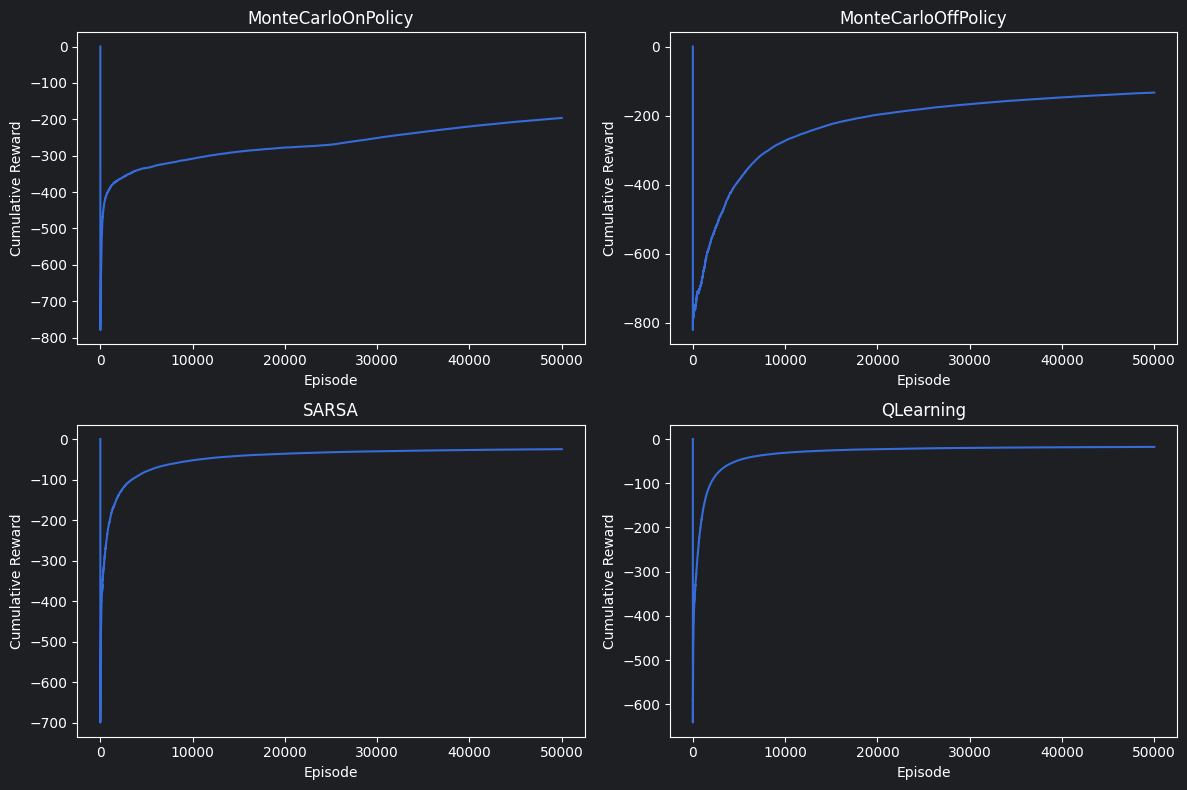

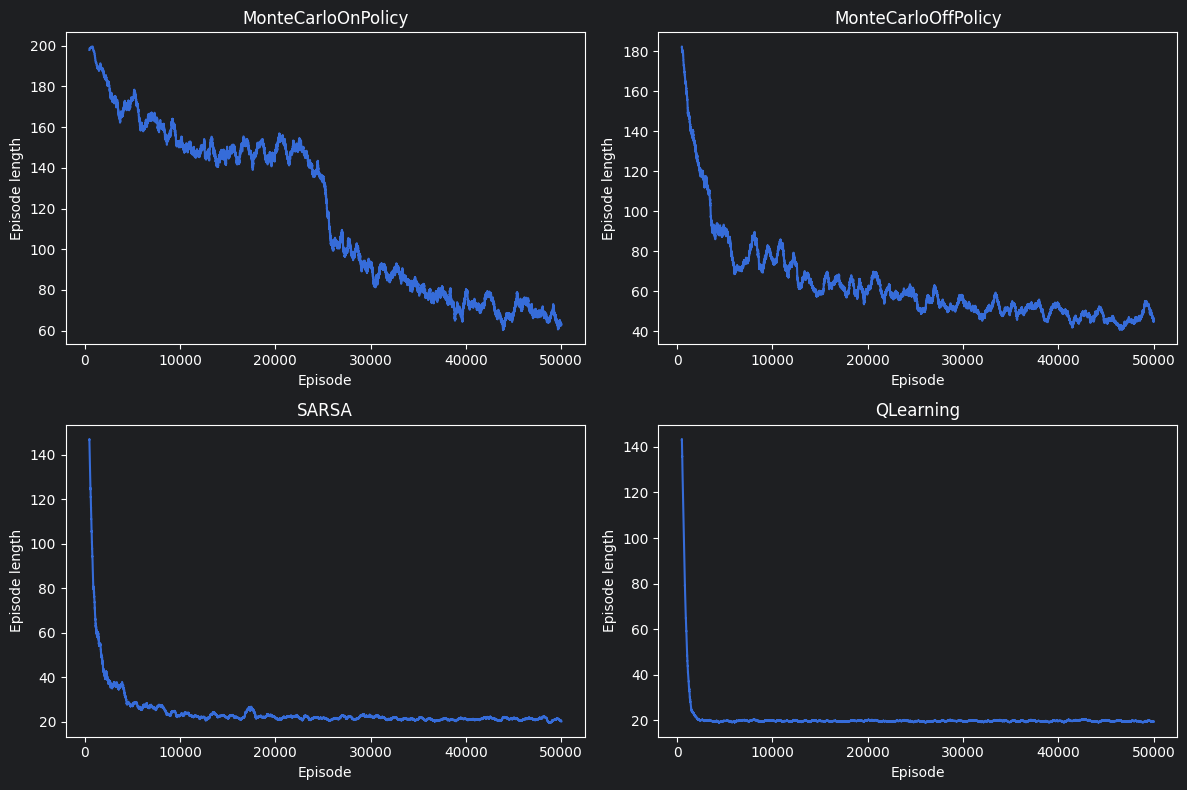

In [15]:
key = (0.3, 1.0)
plot_agent_rewards(results_stats[key])
plot_episode_lengths_for_agents(results_episode_lengths[key])

Procedemos a ejecutar el experimento utilizando **Epsilon Decay**. Como ya no tenemos valores fijos de epsilon, podemos permitirnos dejar este parámetro en el grid con valor a 1.0, pues no se utilizará. La relación que se utilizará para calcular el epsilon será en base a una constante que hemos llamado `decay_factor`, cuyo valor situaremos inicialmente a 1000 (queremos poder modificarlo para controlar como de rápido decrece epsilon):

$\epsilon = decay\_factor / (t + 1)$

Siendo $t$ el número de episodio en el que se encuentra el agente en ese instante.

De esta forma, el agente presentará un comportamiento casi totalmente aleatorio al principio y, conforme avancen los episodios, irá tornándose más greedy, explotando las mejores acciones conocidas en lugar de explorar otras nuevas.

Podemos ver durante el entrenamiento como el valor de epsilon va decayendo conforme pasa el tiempo.

In [22]:

parameters = {
    'epsilon': [1.0],
    'discount_factor': [1.0, 0.9],
    'epsilon_decay': [True]
}

results_q_tables, results_stats, results_episode_lengths, results_correct_finished_episodes, results_avg_correct_episode_lengths = run_experiment_using_grid_search(env, parameters)



Parameter values: epsilon: 1.0, discount_factor: 1.0


Running agent MonteCarloOnPolicy


 10%|█         | 5070/50000 [00:15<01:56, 386.32it/s]

success: -427.5876, epsilon: 0.19996000799840033


 20%|██        | 10103/50000 [00:29<01:42, 390.92it/s]

success: -305.1158, epsilon: 0.0999900009999


...

 82%|████████▏ | 40993/50000 [00:19<00:02, 3067.01it/s]

success: -22.077325, epsilon: 0.02499937501562461


 91%|█████████▏| 45714/50000 [00:20<00:01, 3138.18it/s]

success: -18.886066666666668, epsilon: 0.02222172840603542


100%|██████████| 50000/50000 [00:22<00:00, 2245.99it/s]


Mostramos las estadísticas obtenidas para cada combinación de parámetros, para cada agente.

Podemos ver como los resultados son ahora bastante más favorables que en el caso anterior, como también pasaba con el problema de Frozen Lake. La mayoría de agentes tienen resultados bastante buenos para el número de episodios completados correctamente, así como para la longitud promedio del episodio. Sin embargo, vemos como el algoritmo de Monte Carlo On-Policy ha obtenido resultados peores que en el caso anterior. Para los otros agentes, sin duda el uso de un epsilon decaimiento ha sido positivo una vez más.


In [23]:
for epsilon, discount_factor in itertools.product(parameters["epsilon"], parameters["discount_factor"]):
    print(f'\nParameter values: discount_factor: {discount_factor}\n')
    key = (epsilon, discount_factor)
    print_max_reward_proportion_for_agents(results_stats[key])
    print('\n')
    print_max_correctly_finished_episodes_for_agents(results_correct_finished_episodes[key])
    print('\n')
    print_correct_finished_episodes_length_avg_for_agents(results_avg_correct_episode_lengths[key])


Parameter values: discount_factor: 1.0

[MonteCarloOnPolicy] Máxima proporcion recompensa: -166.65758
[MonteCarloOffPolicy] Máxima proporcion recompensa: -54.3048
[SARSA] Máxima proporcion recompensa: -18.00042
[QLearning] Máxima proporcion recompensa: -16.04368


[MonteCarloOnPolicy] Episodios terminados correctamente: 24664
[MonteCarloOffPolicy] Episodios terminados correctamente: 45726
[SARSA] Episodios terminados correctamente: 48829
[QLearning] Episodios terminados correctamente: 48942


[MonteCarloOnPolicy] Promedio de longitud por episodio completado correctamente: 53.614863769056115
[MonteCarloOffPolicy] Promedio de longitud por episodio completado correctamente: 18.1370992433189
[SARSA] Promedio de longitud por episodio completado correctamente: 15.482500153597247
[QLearning] Promedio de longitud por episodio completado correctamente: 15.19923583016632

Parameter values: discount_factor: 0.9

[MonteCarloOnPolicy] Máxima proporcion recompensa: -227.57142
[MonteCarloOffPolicy] 

Mostramos los mejores resultados de esta ejecución.

En cuanto a episodios completados el ganador es QLearning con 48942 episodios, sin usar un descuento para el retorno futuro. Vemos que son menos episodios completados que en el caso anterior, lo cual podríamos achacar que, quizás, la mayor aleatoriedad que se daba anteriormente hizo al agente aprender antes la política que en este caso, si bien no podemos afirmarlo con rotundidad.

El menor número de pasos lo ha conseguido SARSA con unos 15.2 pasos, lo cual es mejor que en el apartado anterior. Tampoco se usa factor de descuento en este caso.

In [24]:
print_global_best_for_finished_episodes(results_correct_finished_episodes)
print_global_best_for_episodes_length_avg(results_avg_correct_episode_lengths)

El agente que mayor número de episodios ha terminado ha sido: QLearning con 48942 episodios para los parámetros (1.0, 1.0)
El agente que mas rápido ha completado los episodios ha sido: QLearning con 15.19923583016632 pasos en promedio para los parámetros (1.0, 1.0)


Mostramos también las gráficas para el caso que mejor desempeño nos dio anteriormente. En este caso, con discount_factor = 1.0.

Vemos una vez más, si nos fijamos en la recompensa acumulada, como SARSA y Q-Learning se mantienen consistentes presentando un buen rendimiento. Parece que en este caso tarda más en subir la curva que en el apartado anterior, lo que implicaría que han tardado más en aprender la política, probablemente debido a los motivos que ya hemos comentado.

Vemos como Monte Carlo Of-Policy y On-Policy también llegan a aprender como resolver el problema, si bien a este último le ha costado bastante más, presentando un retorno acumulado que crece menos que en el resto de casos.

Por último, vemos como la longitud promedio de los episodios cae rápidamente en casi todos los agentes en cuanto aprenden a resolver el problema, que no es así con Monte Carlo On-Policy, al que parece que le ha costado más en aprender los valores óptimos para cada par estado-acción, y los episodios llegan a tardar bastantes más pasos que para el resto de agentes.


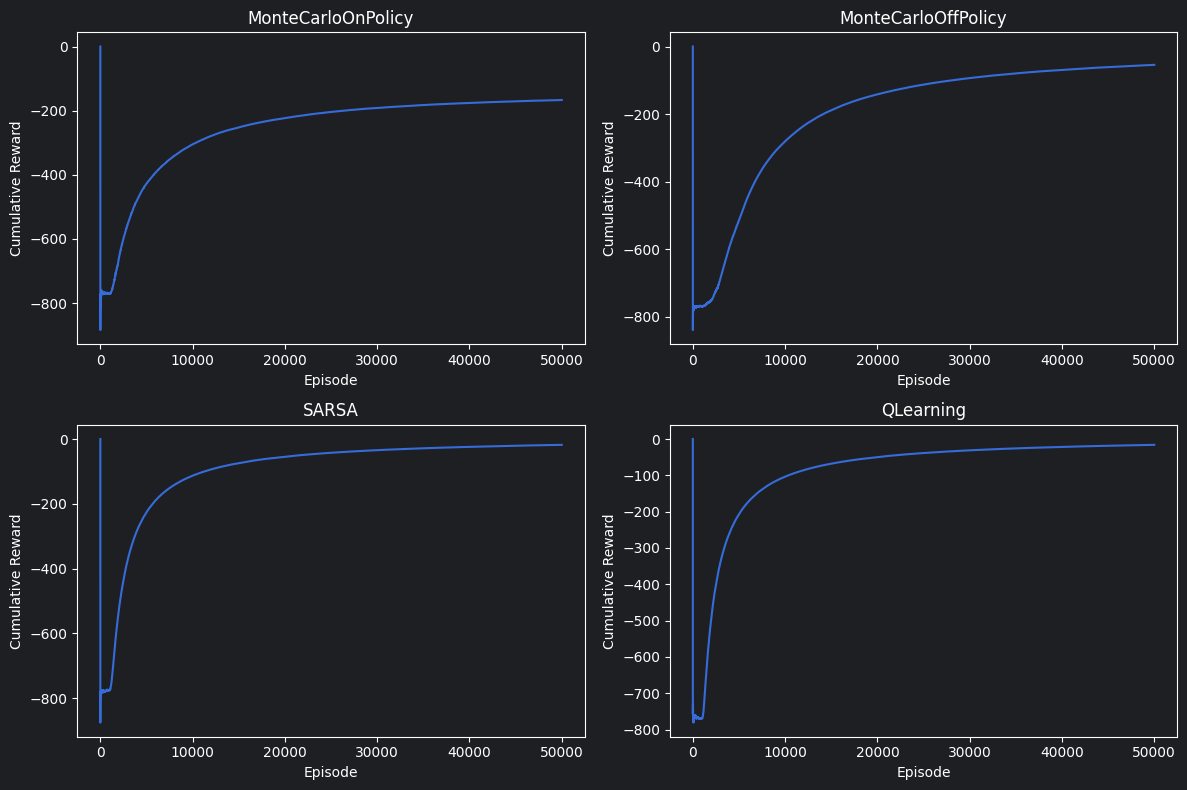

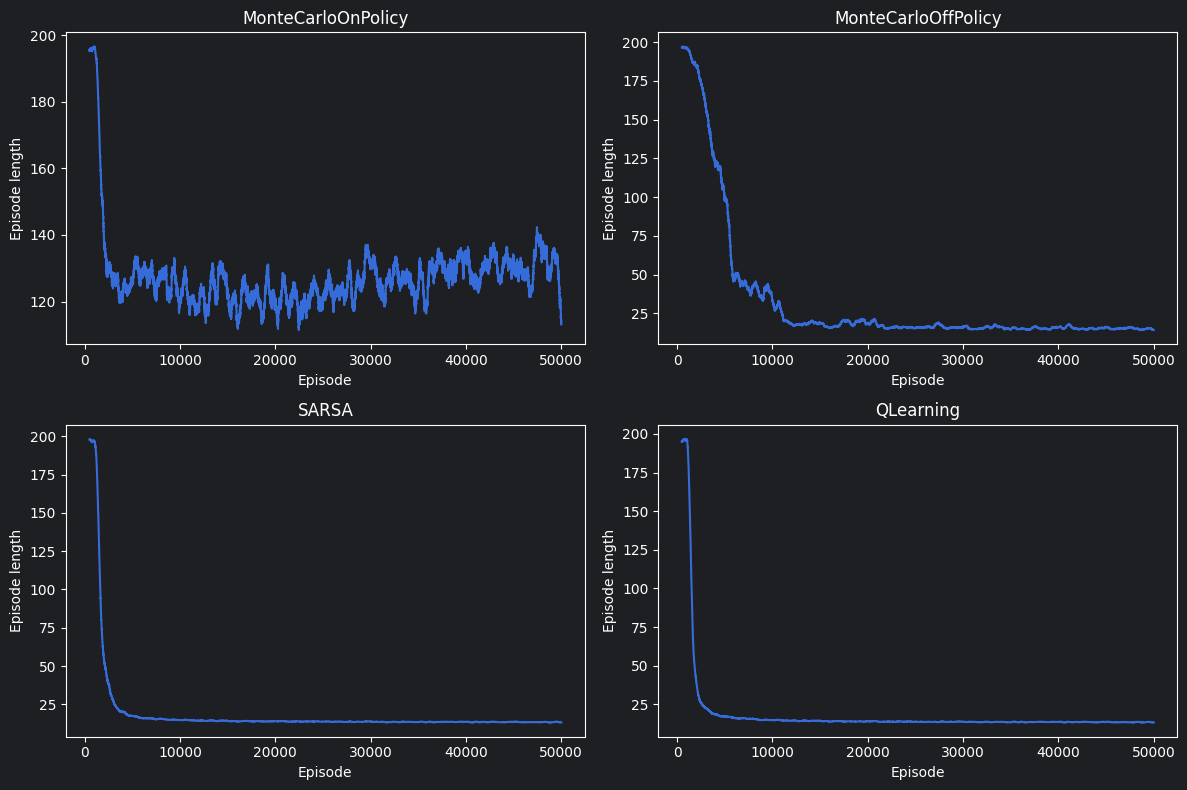

In [25]:
key = (1.0, 1.0)
plot_agent_rewards(results_stats[key])
plot_episode_lengths_for_agents(results_episode_lengths[key])

Vamos a mostrar la tabla Q que ha construído Q-Learning por ejemplo, que es un agente que ha dado buenos resultados de forma consistente.

Dado el número elevado de estados que se contemplan en este problema (puesto que, el taxi puede caer en una casilla aleatoriamente, y el pasajero a recoger en una de las zonas), la tabla no es en sí legible, pero debemos tener en cuenta que **contempla todas las casuísticas que pueden darse en este entorno**, teniendo en cuenta la posición actual del taxi, del pasajero, si llevamos o no al pasajero, etc. Para cada fila (estado), se indica el peso de cada una de las acciones (columnas), y se elegirá preferiblemente aquella con mayor peso.


In [20]:
key = (1.0, 1.0)
q_learning_q = results_q_tables[key]['QLearning']
print(q_learning_q)

[[  0.           0.           0.           0.           0.
    0.        ]
 [  8.9793379    9.88126824   8.97605836   9.94327697  11.
    0.98710599]
 [ 12.98765372  13.9951546   12.99090017  13.99281218  15.
    4.99461449]
 ...
 [  7.17508918  15.99897177   6.08605882   4.93002894  -3.89224466
   -2.19787404]
 [ -2.80111166   1.53507741   1.34555929  11.92519129 -11.72104324
  -10.18743127]
 [ 17.7344463   15.79654967  17.75764527  19.           8.5121581
    8.83824492]]


Imprimimos también la tabla de la política objetivo (pi estrella), en base a la tabla Q y al entorno. Se puede ver como la política se configura en sintonía con la tabla Q que hemos mostrado. Para cada estado, se contempla la acción a realizar. Al ser tan grande, es difícil poder mostrarla en un formato legible.


In [21]:
print_pi_star_from_q(env, q_learning_q)

Política óptima obtenida
 [[0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0.]
 ...
 [0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0.]] 
 Acciones 2, 1, 2, 0, 0, 4, 1, 1, 3, 3, 1, 3, 1, 5,  
 Para el siguiente grid
 +---------+
|R: | : :G|
| : | : : |
| : : : : |
| | : | : |
|Y| : |B: |
+---------+
  (Dropoff)



## **4. Análisis y Estudios Futuros**

En este estudio se ha podido comprobar como los distintos tipos de agentes que utilizan aprendizaje por refuerzo han resultado ser efectivos para la resolución del entorno de Taxi. A continuación, exponemos una serie de puntos que consiguen englobar lo visto y comentado en apartados anteriores.

### **4.1 Análisis de Resultados**

- Los agentes basados en diferencias temporales (SARSA y Q-Learning) han demostrado aprender una política óptima en menor tiempo que las variantes de Monte-Carlo, que únicamente actualizan su tabla Q al final de cada episodio. En este caso, Q-Learning parece ser el que mejores resultados globales nos ha aportado en todos los casos.

- La búsqueda de hiperparámetros ha resultado ser efectiva para optimizar el funcionamiento de los agentes:
  - Un factor de descuento de 1.0 del retorno futuro ha resultado dar mejores resultados, en el caso de utilizar un valor de epsilon fijo. Para epsilon decaimiento, el mejor factor de descuento ha sido también de 1.0 (que no aplica factor de descuento).
  - En caso de utilizar epsilon fijo durante todo el entrenamiento, ha dado mejor resultado utilizar un valor pequeño, como 0.3, al igual que en el problema de Frozen Lake, que valores más grandes, como 0.5. Los agentes se vuelven demasiado aleatorios, sobre todo Monte Carlo On-Policy, que no llega a resolver casi en ningún episodio el problema.

- El uso de epsilon-decay ha demostrado una vez más dar mejor desempeño que un epsilon fijo, al igual que en el problema de Frozen Lake.

- La designación de un conjunto rico de recompensas (-1 por cada paso, -10 por cometer un error, y +20 por dejar a un usuario del taxi) parece tener un efecto positivo que favorece la adecuación de la política óptima cuando se entrena el agente y su pronta convergencia. Creemos, es uno de los motivos por los que SARSA y Q-Learning la aprenden antes que en el problema de Frozen Lake, por ejemplo.


### **4.2 Propuestas para Estudios Futuros**

- Se podría ampliar la experimentación probando también con valores más grandes para el número de episodios, sobre todo en los casos de las variantes de Monte Carlo.

- Sería interesante probar con diferentes valores para el `learning rate` para SARSA y Q-Learning en el grid de parámetros para ver si mejoran su desempeño con respecto, por ejemplo, a Monte Carlo.

- Adicionalmente, supondría un reto para los agentes utilizar la opción de `is_rainy=True` y `fickle_passenger=True` en el entorno, lo que aumentaría la dificultad para llegar al objetivo.